In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [3]:
# 1. Load dataset
dataset = pd.read_csv("letter-recognition.data", header=None)

In [4]:

# 2. Split features and labels
X = dataset.iloc[:, 1:17].values
y = dataset.iloc[:, 0].values

In [5]:
# 3. Encode labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

In [6]:
# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=10
)

In [7]:
# 5. Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# 6. Build model
model = Sequential([
    Dense(128, activation='relu', input_shape=(16,)),
    Dense(64, activation='relu'),
    Dense(26, activation='softmax')
])

In [9]:
# 7. Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# 8. Train model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/20
400/400 [==============================] - 3s 4ms/step - loss: 1.5501 - accuracy: 0.5929 - val_loss: 0.9000 - val_accuracy: 0.7444
Epoch 2/20
400/400 [==============================] - 1s 3ms/step - loss: 0.7292 - accuracy: 0.7924 - val_loss: 0.6713 - val_accuracy: 0.7950
Epoch 3/20
400/400 [==============================] - 1s 2ms/step - loss: 0.5583 - accuracy: 0.8401 - val_loss: 0.5409 - val_accuracy: 0.8353
Epoch 4/20
400/400 [==============================] - 1s 2ms/step - loss: 0.4536 - accuracy: 0.8691 - val_loss: 0.4606 - val_accuracy: 0.8647
Epoch 5/20
400/400 [==============================] - 1s 2ms/step - loss: 0.3807 - accuracy: 0.8904 - val_loss: 0.4080 - val_accuracy: 0.8825
Epoch 6/20
400/400 [==============================] - 1s 2ms/step - loss: 0.3293 - accuracy: 0.9031 - val_loss: 0.3820 - val_accuracy: 0.8819
Epoch 7/20
400/400 [==============================] - 1s 2ms/step - loss: 0.2897 - accuracy: 0.9147 - val_loss: 0.3379 - val_accuracy: 0.8978
Epoch 

In [11]:
# 9. Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)


125/125 [==============================] - 0s 2ms/step - loss: 0.2012 - accuracy: 0.9377
Accuracy: 0.937749981880188


In [12]:
# 10. Predictions
pred_labels = np.argmax(model.predict(X_test), axis=1)
true_labels = np.argmax(y_test, axis=1)

# Convert to letters
pred_letters = encoder.inverse_transform(pred_labels)
true_letters = encoder.inverse_transform(true_labels)

125/125 [==============================] - 0s 1ms/step



Sample Predictions:
C | C
F | F
O | O
U | U
Y | Y


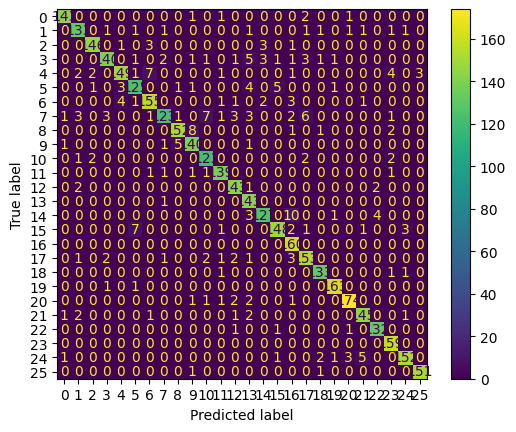

In [13]:
# 11. Show sample predictions (simple)
print("\nSample Predictions:")
for i in range(5):
    print(pred_letters[i], "|", true_letters[i])

# 12. Confusion Matrix (simple)
cm = confusion_matrix(true_labels, pred_labels)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [ ]:
# Reviewing the OCR notebook contents now.

# Read [](file:///c%3A/Users/ADMIN/OneDrive/Desktop/dl/DL_ocr.ipynb)

# ## Line-by-Line Explanation for DL_ocr.ipynb

# ### Cell 1
# `import pandas as pd`  
# - Imports pandas and aliases it as `pd`, used for loading and manipulating tabular data.

# `import numpy as np`  
# - Imports NumPy as `np`, used for numeric operations and array handling.

# `import matplotlib.pyplot as plt`  
# - Imports Matplotlib plotting functions as `plt`, used for visualization.

# `from sklearn.model_selection import train_test_split`  
# - Imports the function to split data into training and testing sets.

# `from sklearn.preprocessing import StandardScaler, LabelEncoder`  
# - Imports:
#   - `StandardScaler` to normalize numeric feature values.
#   - `LabelEncoder` to convert categorical labels into integer codes.

# `from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay`  
# - Imports:
#   - `confusion_matrix` to compute classifier performance.
#   - `ConfusionMatrixDisplay` to plot the confusion matrix.

# `from tensorflow.keras.models import Sequential`  
# - Imports the Keras `Sequential` model container for stacking neural network layers.

# `from tensorflow.keras.layers import Dense`  
# - Imports the `Dense` fully connected layer type for the network.

# `from tensorflow.keras.utils import to_categorical`  
# - Imports utility to convert integer labels into one-hot encoded vectors.

# ---

# ### Cell 2
# `# 1. Load dataset`  
# - A comment indicating the first step is data loading.

# `dataset = pd.read_csv("letter-recognition.data", header=None)`  
# - Loads the letter recognition dataset from a CSV file.
# - `header=None` means the file has no header row, so columns are numbered automatically.

# ---

# ### Cell 3
# `# 2. Split features and labels`  
# - A comment describing the next operation.

# `X = dataset.iloc[:, 1:17].values`  
# - Selects columns 1 through 16 as features (`X`).
# - `.iloc[:, 1:17]` uses integer-location indexing.
# - `.values` converts the DataFrame slice to a NumPy array.

# `y = dataset.iloc[:, 0].values`  
# - Selects column 0 as the label column (`y`), containing the letter class.
# - `.values` converts it to a NumPy array.

# ---

# ### Cell 4
# `# 3. Encode labels`  
# - A comment explaining that label encoding follows.

# `encoder = LabelEncoder()`  
# - Creates a `LabelEncoder` object to transform letters into numeric codes.

# `y_encoded = encoder.fit_transform(y)`  
# - Learns the mapping from letters to integers and applies it to `y`.
# - Example: `A` → 0, `B` → 1, ..., depending on the dataset.

# `y_categorical = to_categorical(y_encoded)`  
# - Converts the integer labels into one-hot encoded vectors.
# - This is required for multiclass classification with `categorical_crossentropy`.

# ---

# ### Cell 5
# `# 4. Train-test split`  
# - A comment describing the dataset split step.

# `X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=10)`  
# - Splits the data into training and testing sets.
# - `test_size=0.2` means 20% of examples become the test set.
# - `random_state=10` makes the split reproducible.

# ---

# ### Cell 6
# `# 5. Feature scaling`  
# - A comment indicating normalization of features.

# `scaler = StandardScaler()`  
# - Creates a scaler that standardizes features to zero mean and unit variance.

# `X_train = scaler.fit_transform(X_train)`  
# - Learns scaling parameters from `X_train` and applies them to `X_train`.

# `X_test = scaler.transform(X_test)`  
# - Applies the same transformation to `X_test` using the parameters learned from training data.

# ---

# ### Cell 7
# `# 6. Build model`  
# - A comment introducing model construction.

# `model = Sequential([`  
# - Starts building a sequential neural network.

# `    Dense(128, activation='relu', input_shape=(16,)),`  
# - Adds a dense layer with 128 neurons and ReLU activation.
# - `input_shape=(16,)` tells the model that each input sample has 16 features.

# `    Dense(64, activation='relu'),`  
# - Adds a second dense hidden layer with 64 neurons and ReLU activation.

# `    Dense(26, activation='softmax')`  
# - Adds the output layer with 26 neurons, one per letter class.
# - `softmax` converts outputs to probabilities over the 26 classes.

# `])`  
# - Ends model definition.

# ---

# ### Cell 8
# `# 7. Compile model`  
# - A comment explaining model compilation.

# `model.compile(`  
# - Begins compiling the model with optimizer, loss, and metrics.

# `    optimizer='adam',`  
# - Uses the Adam optimizer for gradient descent.

# `    loss='categorical_crossentropy',`  
# - Uses categorical crossentropy loss, appropriate for multiclass classification with one-hot labels.

# `    metrics=['accuracy']`  
# - Requests accuracy to be tracked during training and evaluation.

# `)`  
# - Completes model compilation.

# ---

# ### Cell 9
# `# 8. Train model`  
# - A comment describing the training step.

# `history = model.fit(`  
# - Starts training and stores training history.

# `    X_train, y_train,`  
# - Uses the training data features and labels.

# `    epochs=20,`  
# - Trains for 20 full passes over the training data.

# `    batch_size=32,`  
# - Updates weights after every 32 samples.

# `    validation_split=0.2`  
# - Reserves 20% of the training set for validation during training.

# `)`  
# - Completes model fitting.

# ---

# ### Cell 10
# `# 9. Evaluate model`  
# - A comment explaining evaluation on test data.

# `loss, accuracy = model.evaluate(X_test, y_test)`  
# - Evaluates model performance on the held-out test set and returns loss and accuracy.

# `print("Accuracy:", accuracy)`  
# - Prints the test accuracy.

# ---

# ### Cell 11
# `# 10. Predictions`  
# - A comment marking the prediction step.

# `pred_labels = np.argmax(model.predict(X_test), axis=1)`  
# - Predicts class probabilities for `X_test`.
# - `np.argmax(..., axis=1)` selects the class with highest probability for each sample.

# `true_labels = np.argmax(y_test, axis=1)`  
# - Converts one-hot encoded true labels back to integer class labels.

# `# Convert to letters`  
# - A comment indicating label decoding.

# `pred_letters = encoder.inverse_transform(pred_labels)`  
# - Converts predicted integer labels back to original letter labels.

# `true_letters = encoder.inverse_transform(true_labels)`  
# - Converts true integer labels back to original letter labels.

# ---

# ### Cell 12
# `# 11. Show sample predictions (simple)`  
# - A comment explaining sample output display.

# `print("\nSample Predictions:")`  
# - Prints a header for the sample predictions.

# `for i in range(5):`  
# - Loops over the first five test samples.

# `    print(pred_letters[i], "|", true_letters[i])`  
# - Prints the predicted letter and actual letter side by side.

# `# 12. Confusion Matrix (simple)`  
# - A comment for confusion matrix generation.

# `cm = confusion_matrix(true_labels, pred_labels)`  
# - Computes the confusion matrix from actual vs predicted labels.

# `ConfusionMatrixDisplay(cm).plot()`  
# - Creates a visual display of the confusion matrix.

# `plt.show()`  
# - Shows the plot.

# ---

# ### Cell 13
# - Empty cell with no code.

In [ ]:
# ## Expected Viva Questions with Answers for DL_ocr.ipynb

# ### Dataset and preprocessing
# 1. **What dataset is used in this notebook?**  
#    - The letter recognition dataset loaded from `letter-recognition.data`.

# 2. **What do the features represent?**  
#    - Columns 1 to 16 are numeric attributes extracted from letter images.

# 3. **What is the target variable?**  
#    - Column 0, which contains the letter label (A–Z).

# 4. **Why is `LabelEncoder` used?**  
#    - To convert letter labels into integer class IDs that the model can use.

# 5. **Why is `to_categorical()` applied to labels?**  
#    - To convert integer labels into one-hot encoded format for multiclass classification.

# 6. **Why split the dataset with `train_test_split(..., test_size=0.2)`?**  
#    - To reserve 20% of the data for testing and evaluate generalization.

# 7. **Why is feature scaling performed with `StandardScaler`?**  
#    - To normalize each feature to zero mean and unit variance, helping the neural network train better.

# ---

# ### Model architecture
# 8. **Why is `Sequential()` used?**  
#    - Because the model is a simple linear stack of layers.

# 9. **What does `Dense(128, activation='relu', input_shape=(16,))` do?**  
#    - Adds a hidden layer with 128 neurons, ReLU activation, and expects 16 input features.

# 10. **Why is there a second hidden layer `Dense(64, activation='relu')`?**  
#     - To allow the network to learn more complex feature combinations.

# 11. **Why is the final layer `Dense(26, activation='softmax')`?**  
#     - Because there are 26 letter classes and softmax outputs class probabilities.

# 12. **Why use `softmax` instead of `sigmoid` in the output layer?**  
#     - Softmax is appropriate for multiclass classification with mutually exclusive classes.

# ---

# ### Training
# 13. **Why compile with `optimizer='adam'`?**  
#     - Adam is an efficient adaptive optimizer that works well for many networks.

# 14. **Why is `loss='categorical_crossentropy'` used?**  
#     - Because the task is multiclass classification with one-hot encoded labels.

# 15. **What does `metrics=['accuracy']` measure?**  
#     - The fraction of test samples predicted correctly.

# 16. **Why use `epochs=20` and `batch_size=32`?**  
#     - It trains the model over 20 passes of the data with updates every 32 samples.

# 17. **What does `validation_split=0.2` do?**  
#     - It keeps 20% of training data aside for validation during training.

# ---

# ### Evaluation
# 18. **What does `model.evaluate(X_test, y_test)` return?**  
#     - The test loss and accuracy on unseen data.

# 19. **Why use `np.argmax(model.predict(X_test), axis=1)`?**  
#     - To convert the model’s probability outputs into predicted class labels.

# 20. **Why do we use `encoder.inverse_transform(pred_labels)`?**  
#     - To convert predicted integer class IDs back into actual letter labels.

# 21. **What does the confusion matrix show?**  
#     - How many samples were correctly or incorrectly predicted for each letter class.

# ---

# ### Theory and improvement
# 22. **Why is one-hot encoding necessary for this model?**  
#     - Because categorical crossentropy requires label vectors, not scalar class IDs.

# 23. **What is the benefit of using `StandardScaler` before training?**  
#     - It prevents features with larger ranges from dominating and speeds up convergence.

# 24. **How could you improve this model?**  
#     - More hidden layers, regularization, more training data, or using a more advanced architecture.

# 25. **What kind of problem is letter recognition in this notebook?**  
#     - Multiclass classification.

# 26. **Why is a neural network suitable here?**  
#     - It can learn nonlinear relationships between the 16 extracted features and letter classes.

# 27. **What is overfitting and how might you detect it?**  
#     - Overfitting is when the model performs well on training data but poorly on unseen data; detect it if validation accuracy is much lower than training accuracy.

# 28. **Why use a test set instead of evaluating on training data?**  
#     - To measure real performance on unseen examples and avoid optimistic bias.

# 29. **What does `input_shape=(16,)` mean?**  
#     - Each input sample has 16 features.

# 30. **Why is `random_state=10` used in `train_test_split`?**  
#     - To make the split reproducible so results are consistent across runs.